# Setup
Below is how to

In [1]:
import sys
sys.path.append('/projects/seacas/linux/current/lib/')
from pancax import *

##################
# for reproducibility
##################
key = random.key(100)

##################
# file management
##################
full_field_data_file = './data/dic_dataset_0.csv'
global_data_file = './data/mts_dataset.csv'
mesh_file = './mesh/mesh.g'
print(mesh_file)


2024-12-09 12:44:39.521496: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


./mesh/mesh.g


# Domain setup
Below we setup a list of times to evaluate physics quantities such as energy, force, et.c on as well as a ``VariationalDomain`` since we will be using a variational formulation of solid mechanics. This object holds onto several things such as a list of active dofs, shape functions, and other useful things from FEM.

In [2]:
##################
# domain setup
##################
times = jnp.linspace(0., 1., 11)
domain = VariationalDomain(mesh_file, times)

Time in read_exodus_mesh: 0.28297501 seconds
Time in Reading Mesh...: 0.29633013 seconds
Time in QuadratureRule.__init__: 0.12017338 seconds
Time in NonAllocatedFunctionSpace.__init__: 0.63355184 seconds
Time in QuadratureRule.__init__: 0.06621989 seconds
Time in NonAllocatedFunctionSpace.__init__: 0.58249328 seconds


# Full field data processing
We can load the fullfield data as follows

In [3]:
##################
# data setup
##################
field_data = FullFieldData(
  full_field_data_file, 
  ['x', 'y', 'z', 't'], 
  ['u_x', 'u_y', 'u_z']
)

However data is not currently registered as can bee see with the plotting method below

here


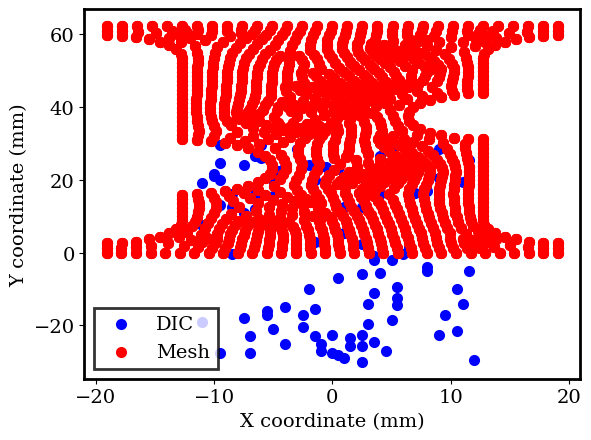

In [4]:
# sanity check plots
field_data.plot_registration(domain)
plt.show()

As can bee seen above, the data and physics mesh are not currently aligned/registered. To alleviate this, we can shift the data as follows (TODO add a helper method)

here


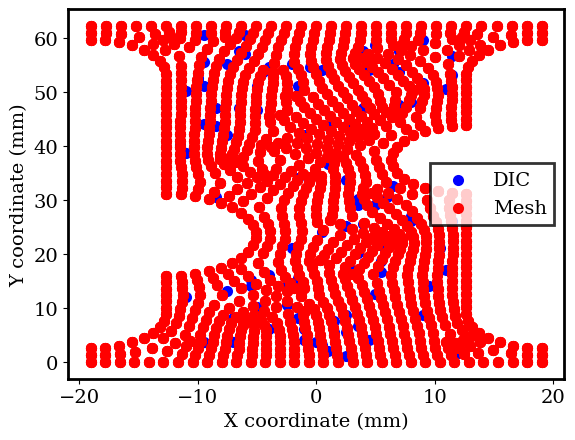

In [5]:
# shift data in y
field_data = field_data.shift_inputs(0., 31.115, 0.)
# get z coordinate correct
field_data = field_data.set_input_component_values('z', 1.905)

# sanity check plots
field_data.plot_registration(domain)
plt.show()

Now data is properly aligned.

# Global data processing
Below is how we can load in global data


You are using exodus.py v 1.21.3 (seacas-py3), a python wrapper of some of the exodus library.

Copyright (c) 2013-2023 National Technology &
Engineering Solutions of Sandia, LLC (NTESS).  Under the terms of
Contract DE-NA0003525 with NTESS, the U.S. Government retains certain
rights in this software.

Opening exodus file: ./mesh/mesh.g


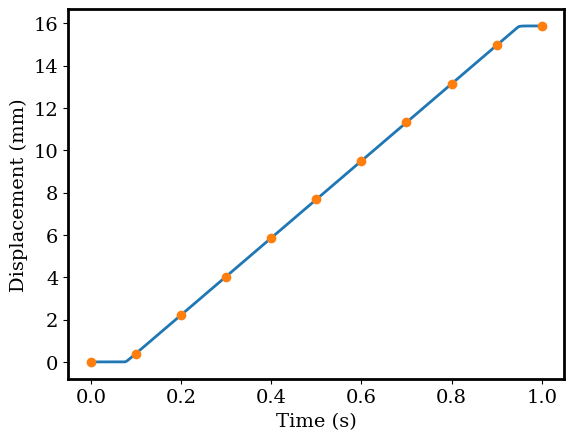

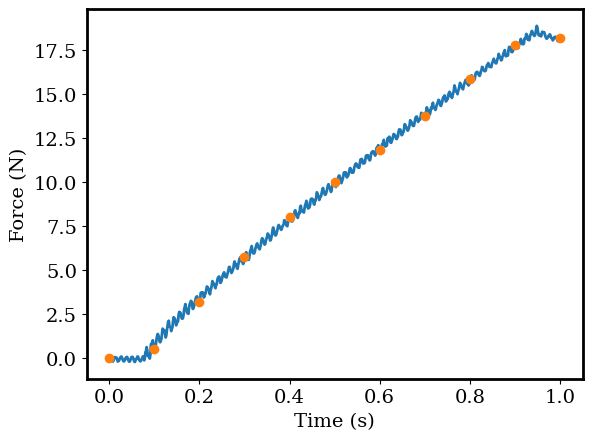

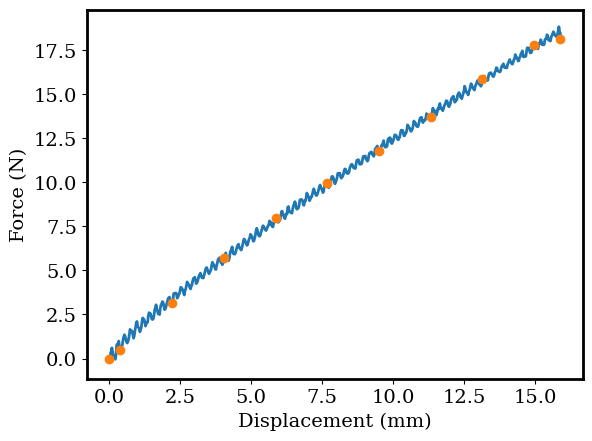

In [6]:
global_data = GlobalData(
  global_data_file,
  'times', 'displacement', 'force',
  mesh_file, 2, 'y', # these inputs specify where to measure reactions
  n_time_steps=11, # the number of time steps for inverse problems is specified here
  plotting=True # for sanity check
)
plt.show()

# Physics setup
Below setups up a simple material model (the NeoHookean model) in such a way that during training the bulk modulus is fixed but teh shear modulus is allowed to vary between 0.01MPa and 10.MPa 

In [7]:
##################
# physics setup
##################
model = NeoHookean(
  bulk_modulus=980.0,
  shear_modulus=BoundedProperty(0.01, 10., key=key)
)
physics = SolidMechanics(model, ThreeDimensional())

# Boundary Conditions
Unfortunately, needed to resort to enforcing BCs weakly due to some dirty meshes from Cubit.

In [8]:
##################
# ics/bcs setup
##################
ics = [
]
essential_bcs = [
  EssentialBC('nset_bottom', 0),
  EssentialBC('nset_bottom', 1),
  EssentialBC('nset_bottom', 2),
  EssentialBC('nset_top', 0),
  EssentialBC('nset_top', 1, lambda x, t: -jnp.max(global_data.displacements) * t),
  EssentialBC('nset_top', 2) 
]
natural_bcs =[
]

# Problem setup

In [9]:
##################
# problem setup
##################
problem = InverseProblem(domain, physics, ics, essential_bcs, natural_bcs, field_data, global_data)


Time in DofManager.__init__: 0.12684109 seconds


# ML setup

In [10]:
##################
# ML setup
##################
field_network = MLP(3 + 1, 3, 100, 3, jax.nn.tanh, key)
params = FieldPropertyPair(field_network, problem.physics)
print(params)

FieldPropertyPair(
  fields=MLP(
    layers=(
      Linear(
        weight=f32[100,4],
        bias=f32[100],
        in_features=4,
        out_features=100,
        use_bias=True
      ),
      Linear(
        weight=f32[100,100],
        bias=f32[100],
        in_features=100,
        out_features=100,
        use_bias=True
      ),
      Linear(
        weight=f32[100,100],
        bias=f32[100],
        in_features=100,
        out_features=100,
        use_bias=True
      ),
      Linear(
        weight=f32[3,100],
        bias=None,
        in_features=100,
        out_features=3,
        use_bias=False
      )
    ),
    activation=<wrapped function tanh>,
    final_activation=<function <lambda>>,
    use_bias=True,
    use_final_bias=False,
    in_size=4,
    out_size=3,
    width_size=100,
    depth=3
  ),
  properties=SolidMechanics(
    field_value_names=('displ_x', 'displ_y', 'displ_z'),
    var_name_to_method={
      'field_values':
      {
        'method':
        _JitW

# Train Network



In [11]:
loss_function_1 = CombineLossFunctions(
  EnergyLoss(),
  DirichletBCLoss(weight=1.e4)
)
loss_function_2 = CombineLossFunctions(
  EnergyResidualAndReactionLoss(energy_weight=1.0, residual_weight=1.e9, reaction_weight=1.e9),
  DirichletBCLoss(1.e9),
  FullFieldDataLoss(weight=1.e9),
)

opt_1 = Adam(loss_function_1, learning_rate=1.0e-3, has_aux=True)#, filter_spec=filter_spec_1)
opt_2 = Adam(loss_function_2, learning_rate=1.0e-3, has_aux=True)#, transition_steps=2500, filter_spec=filter_spec_2)

opt_1_st = opt_1.init(params)
opt_2_st = opt_2.init(params)

# Pre-train network on initial guess of properties

In [12]:
# pretrain
for epoch in range(25000):
  params_new, opt_1_st, loss = opt_1.step(params, problem, opt_1_st)

  # freeze props parameter here
  params = eqx.tree_at(lambda p: p.properties, params_new, params.properties)

  if epoch % 100 == 0:
    print(epoch)
    print(loss)
    print(params.properties.constitutive_model.shear_modulus())

params.serialise('pretrained', 0)

0
(Array(882199.2, dtype=float32), {'dirichlet_bc': Array(88.164116, dtype=float32), 'energy': Array(558.0282, dtype=float32)})
5.4117517
100
(Array(103109.32, dtype=float32), {'dirichlet_bc': Array(9.413139, dtype=float32), 'energy': Array(8977.932, dtype=float32)})
5.4117517
200
(Array(22768.805, dtype=float32), {'dirichlet_bc': Array(0.7882692, dtype=float32), 'energy': Array(14886.111, dtype=float32)})
5.4117517
300
(Array(19454.697, dtype=float32), {'dirichlet_bc': Array(0.5510366, dtype=float32), 'energy': Array(13944.332, dtype=float32)})
5.4117517
400
(Array(16939.938, dtype=float32), {'dirichlet_bc': Array(0.3641706, dtype=float32), 'energy': Array(13298.23, dtype=float32)})
5.4117517
500
(Array(14813.673, dtype=float32), {'dirichlet_bc': Array(0.22543392, dtype=float32), 'energy': Array(12559.334, dtype=float32)})
5.4117517
600
(Array(12919.797, dtype=float32), {'dirichlet_bc': Array(0.13754082, dtype=float32), 'energy': Array(11544.389, dtype=float32)})
5.4117517
700
(Array(

# Stagerred training algorithm

Run n1 iterations where only the displacement ML parameters are allowed to change

Then run n2 iterations where only the properties are allowed to change

These two different updates use two different losses as outlined above.


In [ ]:
for n in range(10000):
  # iterate on field  parameters
  for epoch in range(250):
    params_new, opt_1_st, loss = opt_1.step(params, problem, opt_1_st)  

    # freeze props parameter here
    params = eqx.tree_at(lambda p: p.properties, params_new, params.properties)

  # iterate on props
  for epoch in range(50):
    params_new, opt_2_st, loss = opt_2.step(params, problem, opt_2_st)  

    # freeze field parameter here
    params = eqx.tree_at(lambda p: p.fields, params_new, params.fields)

  print(epoch)
  print(loss)
  print(params.properties.constitutive_model.shear_modulus())

  if n % 10 == 0:
    params.serialise(f'restart', n)

49
(Array(2.0884847e+13, dtype=float32), {'dirichlet_bc': Array(0.03001353, dtype=float32), 'energy': Array(8254.43, dtype=float32), 'field_data_loss': Array(9.472211, dtype=float32), 'global_data_loss': Array(20777.656, dtype=float32), 'reactions': Array([  -6.355023,  -23.531666,  -36.0522  ,  -54.950596,  -83.315346,
       -116.37088 , -135.5163  , -150.89096 , -187.62677 , -204.73955 ,
       -224.11641 ], dtype=float32), 'residual': Array(97.68686, dtype=float32)})
5.2876606
Serialising current parameters to restart_0000000.eqx
49
(Array(1.4645517e+13, dtype=float32), {'dirichlet_bc': Array(0.02873811, dtype=float32), 'energy': Array(8093.8633, dtype=float32), 'field_data_loss': Array(9.45994, dtype=float32), 'global_data_loss': Array(14538.505, dtype=float32), 'reactions': Array([  19.885117 ,    3.6392026,   -6.9317536,  -23.983768 ,
        -51.278854 ,  -84.10603  , -103.787964 , -119.97897  ,
       -157.42169  , -176.66476  , -198.86314  ], dtype=float32), 'residual': Array